<a href="https://colab.research.google.com/github/Lucas-O-S/Modelos_Classificat-rios_IA_N2/blob/main/Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AVALIAÇÃO N2 - Inteligência Artificial

## Dataset: Telco Customer Churn
O conjunto de dados reúne informações sobre clientes de uma empresa de telecomunicações com o objetivo de analisar e prever o cancelamento de clientes (churn) para que, assim, consigam desenvolver estratégias de retenção.

**Nomes e RAs:**

Adriana Kaori Kakazu - 082220004

Beatriz dos Santos Buglio - 082220028

Lucas Oliveira Silva - 082220019

Vitoria Kaori Kuriyama - 082220005

**Modelos de Classificação:**
*   Regressão Logística;
*   Árvore de Decisão;
*   Naive Bayes;
*   KNN;
*   Rede neural (Perceptron simples).

## 1. Configuração do ambiente e carregamento dos dados

In [1]:
# Tratamento dos dados
import numpy as np
import pandas as pd
from collections import Counter

# Carregamento de dados do OpenML
from sklearn.datasets import fetch_openml

# Modelos de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Métricas de avaliação
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay, RocCurveDisplay, confusion_matrix, classification_report
# removed plot_roc_curve as it is deprecated
# Plot dos gráficos
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import colors
import seaborn as sns

#Check scikit-learn version
import sklearn
print(sklearn.__version__) # make sure the version is 0.23 or higher

#If the version is lower than 0.23, update scikit-learn
!pip install -U scikit-learn

1.9.1


In [2]:
# Criação do RANDOM_STATE para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
urlDataset = "https://raw.githubusercontent.com/Lucas-O-S/Modelos_Classificat-rios_IA_N2/refs/heads/main/Telco%20Customer%20Churn.csv"

In [4]:
data = pd.read_csv(urlDataset)

## 2. Fazer a análise exploratória dos dados



### 2.1 Análise e observação dos dados

In [5]:
# Tipos de dado de cada coluna e quantos valores não-nulos existem
print(f"Formato do dataset: {data.shape[0]} linhas x {data.shape[1]} colunas")
data.info()

Formato do dataset: 7043 linhas x 21 colunas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 1

In [6]:
# Analisa se há dados faltantes ou duplicados
missing = data.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Nenhum valor ausente encontrado.")

print(f"Linhas duplicadas: {data.duplicated().sum()}")

Nenhum valor ausente encontrado.
Linhas duplicadas: 0


In [7]:
# Cinco primeiras linhas do dataset
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
# Contagem de quantas vezes cada valor aparece na coluna "Churn"
data['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


É possível ver que os dados são desbalanceados, sendo cerca de 73,5% para "Não" e 26,5% para "Sim".

In [9]:
# Estatísticas básicas das colunas numéricas (média, desvio padrão, mínimo, máximo etc.)
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Aqui percebemos que somente três das vinte colunas apresentam valores numéricos.

In [10]:
# Remoção do "customerID", pois ele não carrega informação preditiva
data_sem_id = data.drop(columns=['customerID'])

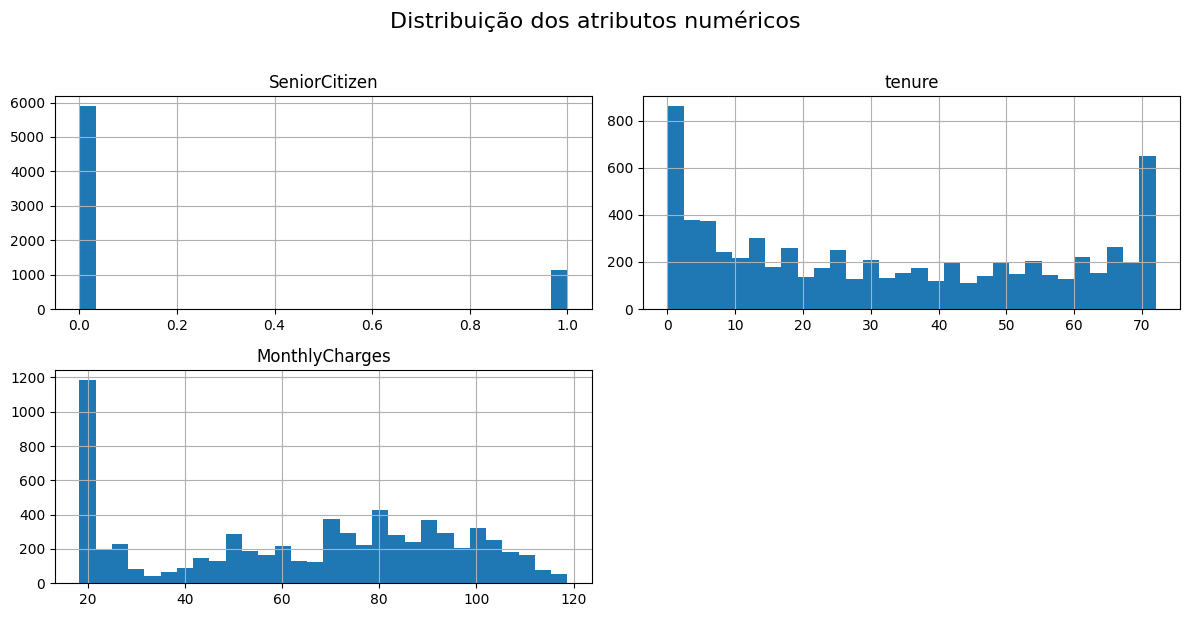

In [11]:
data_sem_id.hist(bins=30, figsize=(12, 6))
plt.suptitle("Distribuição dos atributos numéricos", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Como somente colunas numéricas foram levadas em consideração, percebe-se que a quantidade de features parecem insuficientes.
Para resolver isso, mudamos o tipo de dado das colunas para observar se há resultados interessantes para serem usados no treinamento e teste.

### 2.2 Conversão dos dados

In [12]:
# Inicialmente, como nosso alvo é do tipo object ("Yes"/"No"), convertemos para inteiro
data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})
data["Churn"].dtype

dtype('int64')

In [13]:
# Transformando TotalCharges para um tipo numérico
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data["TotalCharges"].dtype

dtype('float64')

In [14]:
# Testando se houve alterações após a conversão
print(f"Registros com TotalCharges ausente: {data['TotalCharges'].isna().sum()}")
print(f"Linhas duplicadas: {data.duplicated().sum()}")

Registros com TotalCharges ausente: 11
Linhas duplicadas: 0


Onze clientes ficaram com `TotalCharges` ausente, são clientes com `tenure` = 0, ou seja, acabaram de assinar e ainda não fecharam sua primeira fatura.

Logo, por mais que possuam um valor vazio, estes ainda são dados importantes no dataset, portanto iremos transformar esses valores vazios em 0.

In [15]:
# Preenchendo valores vazios com 0
data['TotalCharges'] = data['TotalCharges'].fillna(0)

In [16]:
# Testando novamente
print(f"Registros com TotalCharges ausente: {data['TotalCharges'].isna().sum()}")
print(f"Linhas duplicadas: {data.duplicated().sum()}")

Registros com TotalCharges ausente: 0
Linhas duplicadas: 0


Para o tratamento das variáveis categóricas, utilizamos o método `get_dummies()`, da biblioteca Pandas, que permite transformar variáveis categóricas em variáveis "dummy".

As variáveis dummy são representações numéricas de variáveis categóricas, onde cada categoria é convertida em uma nova coluna binária. Dessa forma, cada coluna indica, por meio dos valores 0 e 1, a ausência ou a presença de determinada categoria em cada observação do conjunto de dados original.

In [17]:
# Separação das colunas entre target, features e colunas para ignorar
coluna_alvo = "Churn"
colunas_para_ignorar = ['customerID']

colunas_para_remover = colunas_para_ignorar + [coluna_alvo]
X = data.drop(columns=colunas_para_remover)
y = data[coluna_alvo]

In [18]:
# Separação das colunas categóricas
colunas_categoricas = X.select_dtypes(include="object").columns.tolist()
print(f"Colunas categóricas ({len(colunas_categoricas)}): {colunas_categoricas}")

Colunas categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [19]:
# Utilização do método "get_dummies()" e visualização do resultado final
X = pd.get_dummies(X, columns=colunas_categoricas, drop_first=True)
print(f"Resultado final: {X.shape}")
X.head()

Resultado final: (7043, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [20]:
# Visualização do dataset depois das alterações
print(f"Formato do dataset: {data.shape[0]} linhas x {data.shape[1]} colunas")
X.info()

Formato do dataset: 7043 linhas x 21 colunas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   gender_Male                            7043 non-null   bool   
 5   Partner_Yes                            7043 non-null   bool   
 6   Dependents_Yes                         7043 non-null   bool   
 7   PhoneService_Yes                       7043 non-null   bool   
 8   MultipleLines_No phone service         7043 non-null   bool   
 9   MultipleLines_Yes                      7043 non-null   bool   
 10  InternetService_Fiber optic

### OBRIGATÓRIO: Explicar quais features estão envolvidas e o seu respectivo target

**Target**

`Churn` - Indica se o cliente cancelou o serviço (Yes = 1) ou permaneceu (No = 0).

**Features**

Todas as colunas, exceto `customerID` e `Churn`.

**Dados demográficos**

* `gender` - gênero do cliente (`Male`/`Female`)
* `SeniorCitizen` - indica se o cliente é idoso (`1`) ou não (`0`)
* `Partner` - indica se possui cônjuge/parceiro(a) (`Yes`/`No`)
* `Dependents` - indica se possui dependentes (`Yes`/`No`)

**Relacionamento com a empresa e serviços contratados**

* `tenure` - tempo, em meses, que o cliente está na empresa
* `PhoneService` - indica se possui serviço de telefonia
* `MultipleLines` - indica se possui múltiplas linhas
* `InternetService` - tipo de serviço de internet (`DSL`, `Fiber optic` ou `None`)
* `OnlineSecurity` - contratação do serviço de segurança online
* `OnlineBackup` - contratação do serviço de backup online
* `DeviceProtection` - contratação de proteção para dispositivos
* `TechSupport` - contratação de suporte técnico
* `StreamingTV` - contratação do serviço de streaming de TV
* `StreamingMovies` - contratação do serviço de streaming de filmes

**Dados contratuais e financeiros**

* `Contract` - tipo de contrato (`mensal`, `1 ano` ou `2 anos`)
* `PaperlessBilling` - indica se a fatura é digital (`Yes`/`No`)
* `PaymentMethod` - forma de pagamento utilizada
* `MonthlyCharges` - valor cobrado mensalmente (numérico)
* `TotalCharges` - valor total cobrado durante o relacionamento com a empresa (numérico)

## 3. Dividir os dados em conjunto de treinamento e treinar os modelos

## 4. Metricas de desempenho

[Precisão, Revocação, Acurácia e F1-Score]

## 5. Conclusão

Os resultados estão bons?